# Plot Fitted Curves for a Single Pixel

This notebook extracts a time-series from a specific pixel, and plots the fitted curves from NuFrost, Zhu2015, and HANTS.

In [25]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CACHE_DIR = PROJECT_DIR / "data" / "cache"
DATA_DIR = PROJECT_DIR / "data" / "input"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"[Info] Project directory: {PROJECT_DIR}")
print(f"[Info] Cache directory: {CACHE_DIR}")
print(f"[Info] Data directory: {DATA_DIR}")

print(f"[Info] Changing working directory to: {PROJECT_DIR}")
os.chdir(str(PROJECT_DIR))

[Info] Project directory: /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost
[Info] Cache directory: /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/data/cache
[Info] Data directory: /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/data/input
[Info] Changing working directory to: /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost


In [26]:
import importlib
from config import build_args
from src.data_loader import RSCube
from src.nufrost import timestamps_to_seconds, predict_curve_pixel as predict_curve_nufrost
from src.zhu2015 import predict_curve_pixel as predict_curve_zhu2015
from src.hants import hants_curve_pixel
import src.nufrost
import src.zhu2015
import src.hants

importlib.reload(src.nufrost)
importlib.reload(src.zhu2015)
importlib.reload(src.hants)

<module 'src.hants' from '/Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/src/hants.py'>

## Configuration

Specify the image name below. Also specify `TARGET_ROW` and `TARGET_COL` to pick a pixel. If you leave them as `None`, the center pixel will be used.

In [27]:
# --- Configuration ---
IMAGE_NAMES = [
    "COPERNICUS_S2_HARMONIZED_B3_lon116.3372_lat31.3563.tif",
]

# Set coordinate (row, col) e.g., (100, 100). Set to None to use the image center.
TARGET_ROW = None
TARGET_COL = None
# ---------------------

print(f"[Info] Number of images to plot: {len(IMAGE_NAMES)}")


[Info] Number of images to plot: 1



========== Processing: COPERNICUS_S2_HARMONIZED_B3_lon116.3372_lat31.3563.tif ==========
[System] Loading from cache: /Users/mckay/Library/CloudStorage/GoogleDrive-yangluhao990714@gmail.com/我的云端硬盘/WorkSpaces/nufrost/data/cache/COPERNICUS_S2_HARMONIZED_B3_lon116.3372_lat31.3563_3966fae49259.npz
[Info] Selected Pixel: (Row=513, Col=597) out of (H=1027, W=1195)
[Info] Original observations: 434 (Valid: 106)
[Info] Target points for curve: 7556
Predicting NuFrost curve...
Predicting Zhu2015 curve...
Predicting HANTS curve...


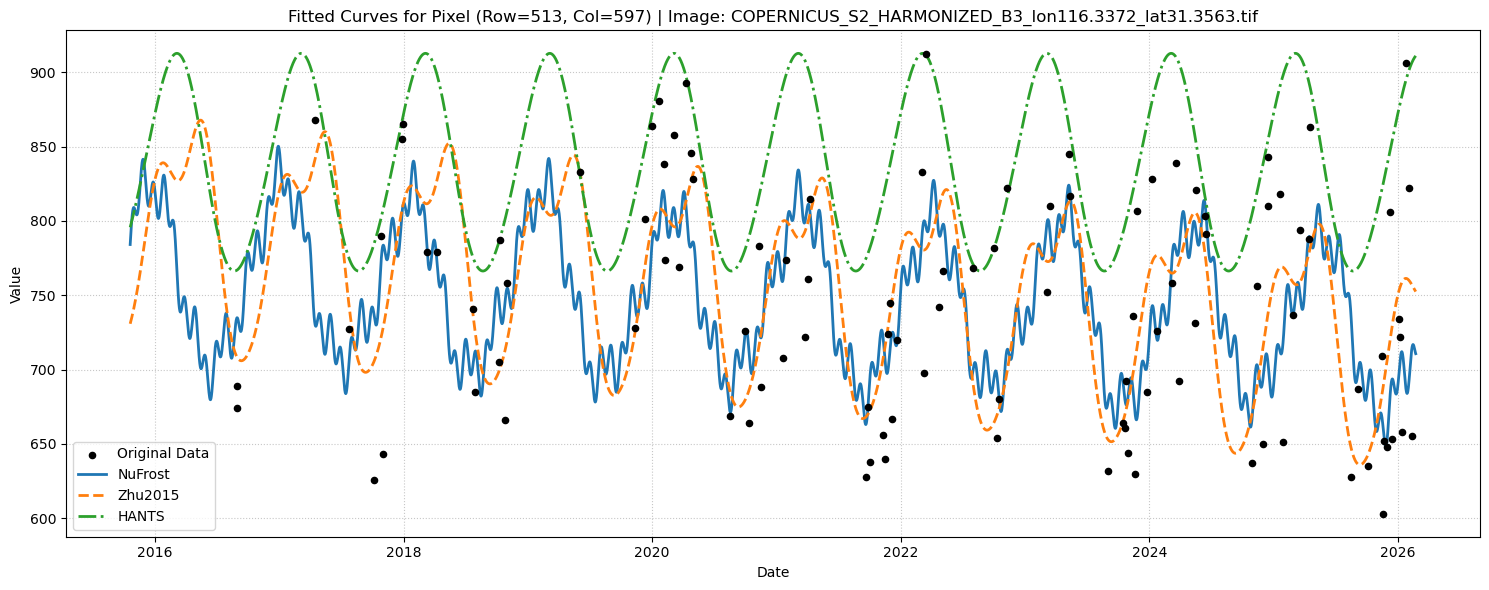

In [28]:
# Load the data and loop over images
for image_name in IMAGE_NAMES:
    print(f"\n========== Processing: {image_name} ==========")
    image_path = DATA_DIR / image_name
    if not image_path.exists():
        print(f"[Error] File not found: {image_path}")
        continue

    loader = RSCube(str(image_path), cache_dir=str(CACHE_DIR))
    data = loader.load()
    cube = data["cube"]
    timestamps = data["timestamps"]

    T, H, W = cube.shape
    r = H // 2 if TARGET_ROW is None else TARGET_ROW
    c = W // 2 if TARGET_COL is None else TARGET_COL

    print(f"[Info] Selected Pixel: (Row={r}, Col={c}) out of (H={H}, W={W})")

    y_ts = cube[:, r, c]
    t_sec = timestamps_to_seconds(timestamps, unit="seconds")
    t0_sec = np.min(t_sec)
    t_days = (t_sec - t0_sec) / 86400.0

    days_range = int(np.ceil(np.max(t_days)))
    target_t_days = np.linspace(0, days_range, days_range * 2)
    target_t_secs = target_t_days * 86400.0 + t0_sec
    target_dates = [pd.Timestamp(t, unit="s") for t in target_t_secs]
    original_dates = [pd.Timestamp(t, unit="s") for t in t_sec]

    print(f"[Info] Original observations: {len(y_ts)} (Valid: {np.sum(np.isfinite(y_ts))})")
    print(f"[Info] Target points for curve: {len(target_t_days)}")

    args = build_args({})
    print("Predicting NuFrost curve...")
    pred_nufrost = predict_curve_nufrost(
        t_sec, y_ts, target_t_secs,
        nufft_modes=args.modes, eps=args.eps,
        num_peaks=args.num_peaks, power_cum=args.power_cum, ignore_dc_hz=args.ignore_dc_hz,
        refine_peaks=args.refine_peaks, include_trend=args.include_trend,
        ridge_lam=args.ridge, freq_weight=args.freq_weight, huber_iters=args.huber_iters, huber_delta=args.huber_delta,
        min_obs=args.min_obs
    )

    print("Predicting Zhu2015 curve...")
    pred_zhu2015 = predict_curve_zhu2015(t_days, y_ts, target_t_days, lasso_alpha=0.0001)

    print("Predicting HANTS curve...")
    pred_hants = hants_curve_pixel(t_days, y_ts, target_t_days, nof=3, sf='low', fet=0.05, dod=5)

    plt.figure(figsize=(15, 6))
    plt.scatter(original_dates, y_ts, color='black', label='Original Data', zorder=5, s=20)
    plt.plot(target_dates, pred_nufrost, label='NuFrost', linewidth=2, color='tab:blue')
    plt.plot(target_dates, pred_zhu2015, label='Zhu2015', linewidth=2, color='tab:orange', linestyle='--')
    plt.plot(target_dates, pred_hants, label='HANTS', linewidth=2, color='tab:green', linestyle='-.')
    plt.title(f"Fitted Curves for Pixel (Row={r}, Col={c}) | Image: {image_name}")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()
